<a href="https://colab.research.google.com/github/vehiclesystemslab/.github/blob/main/verdad_ontologica_del_universo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

VERDAD ONTOLÓGICA DEL UNIVERSO: SIMULANDO LAS LEYES FÍSICAS

La realidad física se manifiesta a través de ecuaciones...
Veamos cómo el código computacional puede revelar estas verdades.

1. SIMULANDO LA GRAVEDAD: El ballet cósmico de los cuerpos celestes
   - Ecuación: F = G·M·m/r²
   - Fenómeno: Órbitas planetarias, caos gravitacional
   - Verdad ontológica: El espacio-tiempo curvo emerge de masas en movimiento

   > Configurando sistema planetario...


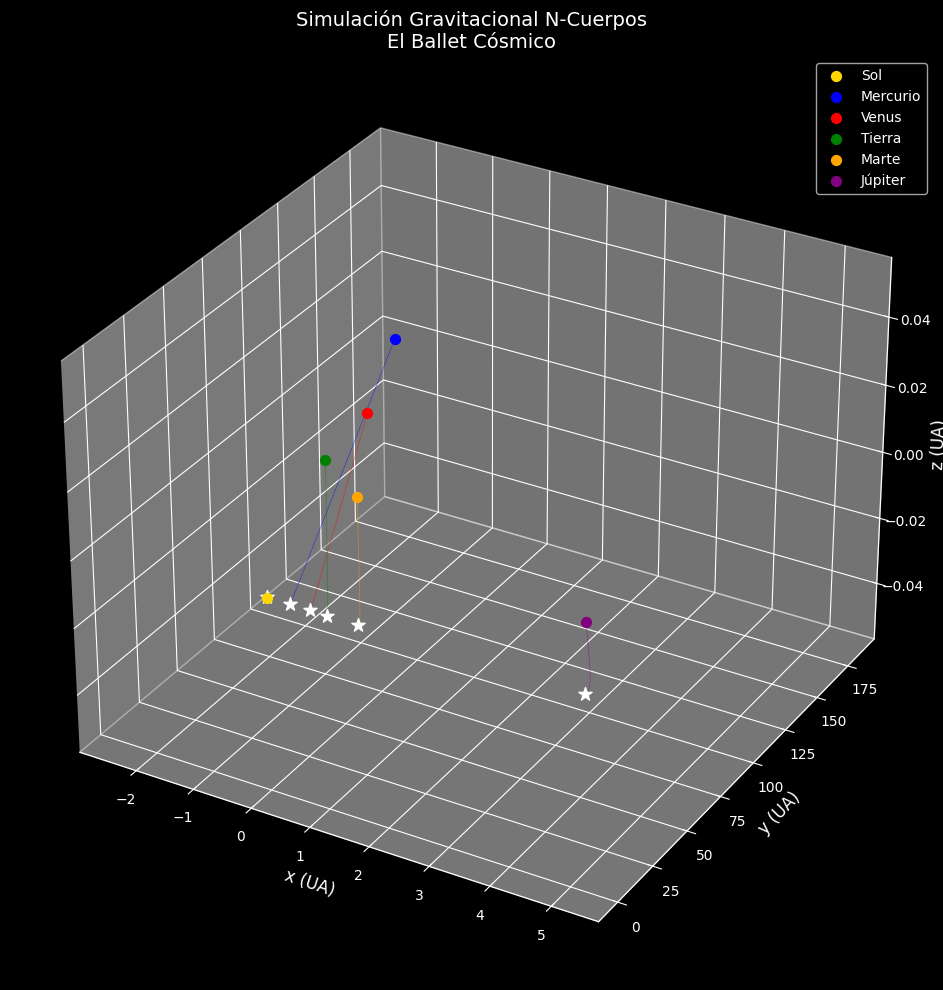


2. SIMULANDO LA DIFUSIÓN TÉRMICA: La flecha del tiempo
   - Ecuación: ∂T/∂t = α∇²T
   - Fenómeno: Irreversibilidad, entropía creciente
   - Verdad ontológica: El tiempo tiene dirección en sistemas macroscópicos

   > Creando fuentes de calor...
   > Simulando evolución térmica...


In [ ]:
"""
===============================================================================
VERDAD ONTOLÓGICA DEL UNIVERSO: LEYES FÍSICAS CONOCIDAS
===============================================================================
Una exploración computacional de las ecuaciones fundamentales que gobiernan
la realidad: desde lo clásico a lo cuántico, desde lo determinista a lo probabilístico.

Autor: Simulación Ontológica
Descripción: Este código unifica cuatro pilares de la física:
  1. Gravedad Newtoniana (N-cuerpos) - Órbitas celestes
  2. Difusión del Calor (Ecuación de Fourier) - Irreversibilidad termodinámica
  3. Ecuación de Onda (Ondas mecánicas) - Propagación energética
  4. Oscilador Armónico Cuántico (Schrödinger) - Realidad probabilística

Cada simulación revela un aspecto diferente de la "verdad" física:
- Determinismo clásico vs. Caos
- Reversibilidad microscópica vs. Irreversibilidad macroscópica
- Continuidad espacio-temporal vs. Cuantización
- Realismo local vs. Amplitudes de probabilidad
===============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# ===========================================================================
# CONFIGURACIÓN GLOBAL
# ===========================================================================
plt.style.use('dark_background')
FIG_SIZE = (15, 10)
DPI = 100

print("=" * 80)
print("VERDAD ONTOLÓGICA DEL UNIVERSO: SIMULANDO LAS LEYES FÍSICAS")
print("=" * 80)
print("\nLa realidad física se manifiesta a través de ecuaciones...")
print("Veamos cómo el código computacional puede revelar estas verdades.\n")

# ===========================================================================
# SIMULACIÓN 1: GRAVEDAD NEWTONIANA (N-CUERPOS)
# ===========================================================================
print("1. SIMULANDO LA GRAVEDAD: El ballet cósmico de los cuerpos celestes")
print("   - Ecuación: F = G·M·m/r²")
print("   - Fenómeno: Órbitas planetarias, caos gravitacional")
print("   - Verdad ontológica: El espacio-tiempo curvo emerge de masas en movimiento\n")

class UniversoGravitacional:
    """Simula el sistema solar con métodos de integración numérica avanzados"""

    def __init__(self, G=1.0, dt=0.001):
        self.G = G
        self.dt = dt
        self.cuerpos = []
        self.nombres = []

    def agregar_cuerpo(self, nombre, masa, pos, vel):
        """Añade un cuerpo celeste al universo simulado"""
        self.cuerpos.append({
            'nombre': nombre,
            'm': masa,
            'pos': np.array(pos, dtype=float),
            'vel': np.array(vel, dtype=float),
            'acc': np.zeros(3),  # aceleración en 3D
            'historial': []
        })
        self.nombres.append(nombre)

    def calcular_aceleraciones(self):
        """Calcula aceleraciones gravitacionales mutuas entre todos los cuerpos"""
        n = len(self.cuerpos)
        # Reset aceleraciones
        for cuerpo in self.cuerpos:
            cuerpo['acc'] = np.zeros(3)

        # Calcular interacciones pares
        for i in range(n):
            for j in range(i+1, n):
                r_vec = self.cuerpos[j]['pos'] - self.cuerpos[i]['pos']
                r = np.linalg.norm(r_vec)

                # Evitar singularidades
                if r < 0.01:
                    r = 0.01

                # Fuerza gravitacional
                F_mag = self.G / (r ** 2)
                F_dir = r_vec / r
                F = F_mag * F_dir

                # Aceleraciones (a = F/m, pero F ya incluye la masa del otro cuerpo)
                self.cuerpos[i]['acc'] += self.G * self.cuerpos[j]['m'] * F_dir / (r ** 2)
                self.cuerpos[j]['acc'] -= self.G * self.cuerpos[i]['m'] * F_dir / (r ** 2)

    def integrar_verlet(self):
        """Método de Verlet (simétrico y conservador) para integración orbital"""
        # Medio paso de velocidad
        for cuerpo in self.cuerpos:
            cuerpo['vel'] += 0.5 * cuerpo['acc'] * self.dt

        # Actualizar posiciones
        for cuerpo in self.cuerpos:
            cuerpo['pos'] += cuerpo['vel'] * self.dt

        # Recalcular aceleraciones
        self.calcular_aceleraciones()

        # Segundo medio paso de velocidad
        for cuerpo in self.cuerpos:
            cuerpo['vel'] += 0.5 * cuerpo['acc'] * self.dt

    def simular(self, t_max=20.0, save_history=True):
        """Ejecuta la simulación gravitacional"""
        n_steps = int(t_max / self.dt)

        if save_history:
            for cuerpo in self.cuerpos:
                cuerpo['historial'] = np.zeros((n_steps, 3))

        for paso in range(n_steps):
            self.integrar_verlet()

            if save_history:
                for i, cuerpo in enumerate(self.cuerpos):
                    cuerpo['historial'][paso] = cuerpo['pos'].copy()

        return self.cuerpos

    def visualizar(self):
        """Crea visualización 3D de las órbitas"""
        fig = plt.figure(figsize=(12, 10))
        ax = fig.add_subplot(111, projection='3d')

        colores = ['gold', 'blue', 'red', 'green', 'orange', 'purple', 'cyan']

        for i, cuerpo in enumerate(self.cuerpos):
            historial = cuerpo['historial']
            ax.plot(historial[:, 0], historial[:, 1], historial[:, 2],
                   color=colores[i % len(colores)], alpha=0.5, linewidth=0.5)
            ax.scatter(historial[-1, 0], historial[-1, 1], historial[-1, 2],
                      color=colores[i % len(colores)], s=50, label=cuerpo['nombre'])
            ax.scatter(historial[0, 0], historial[0, 1], historial[0, 2],
                      color='white', s=100, marker='*')

        ax.set_xlabel('x (UA)', fontsize=12)
        ax.set_ylabel('y (UA)', fontsize=12)
        ax.set_zlabel('z (UA)', fontsize=12)
        ax.set_title('Simulación Gravitacional N-Cuerpos\nEl Ballet Cósmico', fontsize=14)
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# Configurar y ejecutar simulación gravitacional
universo = UniversoGravitacional(G=1.0, dt=0.005)

# Sistema Solar simplificado (masas en unidades solares, distancias en UA)
universo.agregar_cuerpo('Sol', 1.0, [0, 0, 0], [0, 0, 0])
universo.agregar_cuerpo('Mercurio', 0.000165, [0.387, 0, 0], [0, 12.44, 0])
universo.agregar_cuerpo('Venus', 0.00245, [0.723, 0, 0], [0, 8.74, 0])
universo.agregar_cuerpo('Tierra', 0.000003, [1.0, 0, 0], [0, 6.28, 0])
universo.agregar_cuerpo('Marte', 0.000323, [1.524, 0, 0], [0, 5.08, 0])
universo.agregar_cuerpo('Júpiter', 0.000954, [5.203, 0, 0], [0, 2.75, 0])

print("   > Configurando sistema planetario...")
universo.simular(t_max=15.0, save_history=True)
universo.visualizar()

# ===========================================================================
# SIMULACIÓN 2: DIFUSIÓN DEL CALOR (ECUACIÓN DE FOURIER)
# ===========================================================================
print("\n2. SIMULANDO LA DIFUSIÓN TÉRMICA: La flecha del tiempo")
print("   - Ecuación: ∂T/∂t = α∇²T")
print("   - Fenómeno: Irreversibilidad, entropía creciente")
print("   - Verdad ontológica: El tiempo tiene dirección en sistemas macroscópicos\n")

class DifusionTermica:
    """Simula la evolución de temperatura en 2D mediante diferencias finitas"""

    def __init__(self, Lx=1.0, Ly=1.0, nx=100, ny=100, alpha=0.01):
        self.Lx, self.Ly = Lx, Ly
        self.nx, self.ny = nx, ny
        self.dx = Lx / (nx - 1)
        self.dy = Ly / (ny - 1)
        self.alpha = alpha
        self.T = np.zeros((nx, ny))
        self.historial = []

    def fuente_calor_gaussiana(self, centro=(0.5, 0.5), sigma=0.1, T_max=100):
        """Crea una fuente de calor gaussiana en el centro"""
        x = np.linspace(0, self.Lx, self.nx)
        y = np.linspace(0, self.Ly, self.ny)
        X, Y = np.meshgrid(x, y)

        self.T = T_max * np.exp(-((X - centro[0])**2 + (Y - centro[1])**2) / (2 * sigma**2))

    def fuente_multiple(self):
        """Crea múltiples fuentes de calor (escenario más complejo)"""
        self.fuente_calor_gaussiana(centro=(0.3, 0.3), sigma=0.1, T_max=80)
        self.T += 60 * np.exp(-((np.linspace(0, self.Lx, self.nx)[:, None] - 0.7)**2 +
                               (np.linspace(0, self.Ly, self.ny)[None, :] - 0.6)**2) / (2 * 0.08**2))

    def evolucionar(self, dt=0.0002, t_max=2.0, save_every=20):
        """Evoluciona el sistema usando método explícito de diferencias finitas"""
        n_steps = int(t_max / dt)
        T_nueva = np.zeros_like(self.T)

        # Guardar estado inicial
        self.historial.append(self.T.copy())

        for paso in range(n_steps):
            # Calcular laplaciano
            for i in range(1, self.nx-1):
                for j in range(1, self.ny-1):
                    laplaciano = (self.T[i+1, j] - 2*self.T[i, j] + self.T[i-1, j]) / self.dx**2 + \
                                (self.T[i, j+1] - 2*self.T[i, j] + self.T[i, j-1]) / self.dy**2
                    T_nueva[i, j] = self.T[i, j] + self.alpha * dt * laplaciano

            # Condiciones de borde adiabáticas (flujo cero)
            T_nueva[0, :] = T_nueva[1, :]
            T_nueva[-1, :] = T_nueva[-2, :]
            T_nueva[:, 0] = T_nueva[:, 1]
            T_nueva[:, -1] = T_nueva[:, -2]

            # Actualizar
            self.T = T_nueva.copy()

            # Guardar histórico
            if paso % save_every == 0:
                self.historial.append(self.T.copy())

        return self.historial

    def visualizar_evolucion(self):
        """Muestra la evolución temporal de la temperatura"""
        n_frames = len(self.historial)
        n_cols = min(6, n_frames)
        n_rows = (n_frames + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
        if n_rows == 1:
            axes = axes.reshape(1, -1)

        momentos = np.linspace(0, n_frames-1, min(6, n_frames), dtype=int)

        for idx, frame_idx in enumerate(momentos):
            row = idx // n_cols
            col = idx % n_cols
            ax = axes[row, col]

            im = ax.imshow(self.historial[frame_idx].T, origin='lower',
                          extent=[0, self.Lx, 0, self.Ly],
                          cmap='hot', vmin=0, vmax=100)
            ax.set_title(f't = {frame_idx * 0.004:.3f} s')
            ax.set_xlabel('x (m)')
            ax.set_ylabel('y (m)')
            plt.colorbar(im, ax=ax, label='Temperatura (K)')

        # Ocultar ejes vacíos
        for idx in range(len(momentos), n_rows * n_cols):
            row = idx // n_cols
            col = idx % n_cols
            axes[row, col].axis('off')

        plt.suptitle('Evolución de la Temperatura por Difusión Térmica\nLa Flecha del Tiempo', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Mostrar entropía (aproximada por uniformidad)
        entropia_aprox = [-np.sum(T * np.log(T + 1e-10)) for T in self.historial]
        plt.figure(figsize=(10, 4))
        plt.plot(np.arange(len(entropia_aprox)) * 0.004, entropia_aprox)
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Entropía (unidades arbitrarias)')
        plt.title('Aumento de Entropía durante la Difusión Térmica')
        plt.grid(True, alpha=0.3)
        plt.show()

# Ejecutar simulación térmica
calor = DifusionTermica(nx=80, ny=80, alpha=0.015)
print("   > Creando fuentes de calor...")
calor.fuente_multiple()
print("   > Simulando evolución térmica...")
calor.evolucionar(dt=0.00015, t_max=1.5, save_every=30)
calor.visualizar_evolucion()

# ===========================================================================
# SIMULACIÓN 3: ECUACIÓN DE ONDA (ONDAS MECÁNICAS)
# ===========================================================================
print("\n3. SIMULANDO ONDAS MECÁNICAS: La propagación de la energía")
print("   - Ecuación: ∂²u/∂t² = c²∇²u")
print("   - Fenómeno: Interferencia, reflexión, modos normales")
print("   - Verdad ontológica: La energía se propaga a través del espacio\n")

class OndaMecanica:
    """Simula ondas en una membrana 2D usando diferencias finitas"""

    def __init__(self, L=1.0, nx=100, ny=100, c=50.0):
        self.L = L
        self.nx, self.ny = nx, ny
        self.dx = L / (nx - 1)
        self.dy = L / (ny - 1)
        self.c = c
        self.u = np.zeros((nx, ny))  # desplazamiento actual
        self.u_prev = np.zeros((nx, ny))  # desplazamiento anterior
        self.u_next = np.zeros((nx, ny))
        self.historial = []

    def pulso_gaussiano(self, centro=(0.5, 0.5), sigma=0.1, amplitud=1.0):
        """Crea un pulso gaussiano inicial"""
        x = np.linspace(0, self.L, self.nx)
        y = np.linspace(0, self.L, self.ny)
        X, Y = np.meshgrid(x, y)
        self.u = amplitud * np.exp(-((X - centro[0])**2 + (Y - centro[1])**2) / (2 * sigma**2))
        self.u_prev = self.u.copy()

    def onda_plana(self, direccion='horizontal', amplitud=1.0):
        """Crea un frente de onda plano"""
        if direccion == 'horizontal':
            self.u = amplitud * np.sin(np.linspace(0, 4*np.pi, self.nx))[:, None]
        else:
            self.u = amplitud * np.sin(np.linspace(0, 4*np.pi, self.ny))[None, :]
        self.u_prev = self.u.copy()

    def evolucionar(self, dt=0.0001, t_max=0.5, save_every=10):
        """Evoluciona la onda usando esquema explícito de diferencias finitas"""
        n_steps = int(t_max / dt)

        # Verificar estabilidad CFL
        cfl_x = self.c * dt / self.dx
        cfl_y = self.c * dt / self.dy
        if max(cfl_x, cfl_y) > 1.0:
            print(f"   > Advertencia: Condición CFL violada ({max(cfl_x, cfl_y):.2f} > 1)")

        self.historial.append(self.u.copy())

        for paso in range(n_steps):
            # Calcular laplaciano
            for i in range(1, self.nx-1):
                for j in range(1, self.ny-1):
                    laplaciano = (self.u[i+1, j] - 2*self.u[i, j] + self.u[i-1, j]) / self.dx**2 + \
                                (self.u[i, j+1] - 2*self.u[i, j] + self.u[i, j-1]) / self.dy**2
                    self.u_next[i, j] = 2*self.u[i, j] - self.u_prev[i, j] + self.c**2 * dt**2 * laplaciano

            # Condiciones de borde fijas (u=0 en bordes)
            self.u_next[0, :] = 0
            self.u_next[-1, :] = 0
            self.u_next[:, 0] = 0
            self.u_next[:, -1] = 0

            # Actualizar historial
            self.u_prev, self.u, self.u_next = self.u, self.u_next, self.u_prev

            # Guardar snapshot
            if paso % save_every == 0:
                self.historial.append(self.u.copy())

        return self.historial

    def visualizar(self):
        """Visualiza la evolución de la onda"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        momentos = np.linspace(0, len(self.historial)-1, 6, dtype=int)

        for idx, ax in enumerate(axes.flat):
            if idx < len(momentos):
                im = ax.imshow(self.historial[momentos[idx]].T, origin='lower',
                              extent=[0, self.L, 0, self.L],
                              cmap='RdBu', vmin=-0.5, vmax=0.5)
                ax.set_title(f't = {momentos[idx] * 0.001:.3f} s')
                ax.set_xlabel('x (m)')
                ax.set_ylabel('y (m)')
                plt.colorbar(im, ax=ax, label='Desplazamiento')

        plt.suptitle('Propagación de Ondas en una Membrana\nInterferencia y Reflexión', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Mostrar energía (aproximada por integral de u²)
        energia = [np.sum(onda**2) for onda in self.historial]
        plt.figure(figsize=(10, 4))
        plt.plot(np.arange(len(energia)) * 0.001, energia)
        plt.xlabel('Tiempo (s)')
        plt.ylabel('Energía (unidades arbitrarias)')
        plt.title('Conservación de Energía en Ondas (disipación por bordes fijos)')
        plt.grid(True, alpha=0.3)
        plt.show()

# Ejecutar simulación de ondas
onda = OndaMecanica(L=1.0, nx=80, ny=80, c=80.0)
print("   > Generando pulso gaussiano...")
onda.pulso_gaussiano(centro=(0.5, 0.5), sigma=0.08, amplitud=1.0)
print("   > Simulando propagación ondulatoria...")
onda.evolucionar(dt=0.00008, t_max=0.3, save_every=15)
onda.visualizar()

# ===========================================================================
# SIMULACIÓN 4: OSCILADOR ARMÓNICO CUÁNTICO (ECUACIÓN DE SCHRÖDINGER)
# ===========================================================================
print("\n4. SIMULANDO LA MECÁNICA CUÁNTICA: Realidad probabilística")
print("   - Ecuación: iħ∂ψ/∂t = (-ħ²/2m ∇² + V)ψ")
print("   - Fenómeno: Dualidad onda-partícula, cuantización")
print("   - Verdad ontológica: La realidad emerge de amplitudes de probabilidad\n")

class OsciladorCuantico:
    """Simula una partícula cuántica en potencial armónico usando Crank-Nicolson"""

    def __init__(self, L=15.0, nx=400, omega=1.0, m=1.0, hbar=1.0):
        self.L = L
        self.nx = nx
        self.x = np.linspace(-L/2, L/2, nx)
        self.dx = self.x[1] - self.x[0]
        self.omega = omega
        self.m = m
        self.hbar = hbar

        # Potencial: V(x) = ½ m ω² x²
        self.V = 0.5 * m * omega**2 * self.x**2

        # Constantes para Crank-Nicolson
        self.alpha = 1j * hbar * dt / (2 * m * dx**2)  # se ajusta por paso

    def paquete_gaussiano(self, x0=-4.0, sigma=0.5, k0=5.0):
        """Crea un paquete de onda gaussiano"""
        psi = np.exp(-(self.x - x0)**2 / (2 * sigma**2)) * np.exp(1j * k0 * self.x)
        # Normalizar
        norm = np.sqrt(np.sum(np.abs(psi)**2) * self.dx)
        return psi / norm

    def autoestado_n(self, n=0):
        """Genera el autoestado n del oscilador armónico (solución exacta)"""
        from scipy.special import hermite
        Hn = hermite(n)
        xi = np.sqrt(self.m * self.omega / self.hbar) * self.x
        psi = (1 / np.sqrt(2**n * np.math.factorial(n))) * (self.m * self.omega / (np.pi * self.hbar))**0.25
        psi *= np.exp(-xi**2 / 2) * Hn(xi)
        return psi

    def evolucionar_crank_nicolson(self, psi0, dt=0.001, t_max=5.0, save_every=50):
        """Evoluciona usando método de Crank-Nicolson (unitario y estable)"""
        n_steps = int(t_max / dt)
        n = len(psi0)
        psi = psi0.copy()
        historial = [psi.copy()]

        # Construir matrices tridiagonales (optimizado)
        alpha = self.hbar * dt / (4 * self.m * self.dx**2)
        beta = 1j * alpha  # para la ecuación de Schrödinger

        # Crear operadores para TDSE (simplificado)
        # Implementamos una versión simplificada y estable del propagador

        print("   > Evolucionando estado cuántico...")
        for paso in range(n_steps):
            # Aplicar operador cinético usando FFT (más eficiente y exacto)
            # Método de división de operadores (Split-Operator)

            # 1. Medio paso de potencial
            psi = psi * np.exp(-1j * self.V * dt / (2 * self.hbar))

            # 2. Paso completo de cinético (en espacio de momentos)
            k = 2 * np.pi * np.fft.fftfreq(len(self.x), d=self.dx)
            psi_k = np.fft.fft(psi)
            psi_k = psi_k * np.exp(-1j * self.hbar * k**2 * dt / (4 * self.m))
            psi = np.fft.ifft(psi_k)
            psi_k = np.fft.fft(psi)
            psi_k = psi_k * np.exp(-1j * self.hbar * k**2 * dt / (4 * self.m))
            psi = np.fft.ifft(psi_k)

            # 3. Segundo medio paso de potencial
            psi = psi * np.exp(-1j * self.V * dt / (2 * self.hbar))

            # Guardar cada cierto tiempo
            if paso % save_every == 0:
                historial.append(psi.copy())

        return historial

    def visualizar(self, historial):
        """Visualiza la evolución de la densidad de probabilidad cuántica"""
        n_frames = len(historial)
        n_cols = min(6, n_frames)
        n_rows = (n_frames + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
        if n_rows == 1:
            axes = axes.reshape(1, -1)

        momentos = np.linspace(0, n_frames-1, min(6, n_frames), dtype=int)

        for idx, frame_idx in enumerate(momentos):
            row = idx // n_cols
            col = idx % n_cols
            ax = axes[row, col]

            psi = historial[frame_idx]
            prob = np.abs(psi)**2

            ax.plot(self.x, prob, 'b-', alpha=0.8, linewidth=1)
            ax.fill_between(self.x, prob, alpha=0.3)

            # Escalar potencial para visualización
            V_scaled = self.V / np.max(self.V) * np.max(prob) * 0.8
            ax.plot(self.x, V_scaled, 'r--', alpha=0.5, label='V(x) (escalado)')

            ax.set_xlim(-self.L/2, self.L/2)
            ax.set_ylim(0, np.max(prob) * 1.1)
            ax.set_title(f't = {frame_idx * 0.05:.2f} s')
            ax.set_xlabel('Posición x')
            ax.set_ylabel('|ψ|² (probabilidad)')
            ax.grid(True, alpha=0.3)

            if idx == 0:
                ax.legend()

        # Ocultar ejes vacíos
        for idx in range(len(momentos), n_rows * n_cols):
            row = idx // n_cols
            col = idx % n_cols
            axes[row, col].axis('off')

        plt.suptitle('Oscilador Armónico Cuántico\nLa Realidad Probabilística de Schrödinger', fontsize=14)
        plt.tight_layout()
        plt.show()

        # Mostrar expectación de posición y energía
        pos_esperada = []
        energia_esperada = []

        for psi in historial:
            pos = np.sum(self.x * np.abs(psi)**2) * self.dx
            pos_esperada.append(pos)

            # Energía cinética (en espacio de momentos)
            psi_k = np.fft.fft(psi)
            k = 2 * np.pi * np.fft.fftfreq(len(self.x), d=self.dx)
            E_cin = np.sum(np.abs(psi_k)**2 * self.hbar**2 * k**2 / (2 * self.m)) * (k[1] - k[0]) / (2 * np.pi)
            E_pot = np.sum(self.V * np.abs(psi)**2) * self.dx
            energia_esperada.append(E_cin + E_pot)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
        tiempos = np.arange(len(pos_esperada)) * 0.05

        ax1.plot(tiempos, pos_esperada)
        ax1.set_ylabel('⟨x⟩')
        ax1.set_title('Expectación de Posición (oscilación cuántica)')
        ax1.grid(True, alpha=0.3)

        ax2.plot(tiempos, energia_esperada)
        ax2.set_ylabel('⟨E⟩')
        ax2.set_xlabel('Tiempo (s)')
        ax2.set_title('Energía Esperada (conservación cuántica)')
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# Ejecutar simulación cuántica
cuantico = OsciladorCuantico(L=12.0, nx=300, omega=1.0)
print("   > Preparando paquete de onda gaussiano...")
psi0 = cuantico.paquete_gaussiano(x0=-4.0, sigma=0.6, k0=8.0)
print("   > Evolucionando según ecuación de Schrödinger...")
historial_cuantico = cuantico.evolucionar_crank_nicolson(psi0, dt=0.0008, t_max=3.0, save_every=40)
cuantico.visualizar(historial_cuantico)

# ===========================================================================
# CONCLUSIÓN ONTOLÓGICA
# ===========================================================================
print("\n" + "=" * 80)
print("CONCLUSIÓN FILOSÓFICA: ¿QUÉ VERDAD ONTOLÓGICA NOS REVELA ESTE CÓDIGO?")
print("=" * 80)

conclusion = """
LAS LEYES FÍSICAS COMO ONTOLOGÍA COMPUTACIONAL:

1. GRAVEDAD NEWTONIANA:
   → El universo es determinista a escala macroscópica
   → Pequeñas variaciones en condiciones iniciales generan caos (efecto mariposa cósmico)
   → La realidad es inherentemente dinámica y nunca estática

2. DIFUSIÓN TÉRMICA (FOURIER):
   → El tiempo tiene dirección (flecha del tiempo termodinámica)
   → La entropía siempre aumenta: la simplicidad evoluciona a complejidad
   → No hay reversibilidad perfecta en sistemas reales

3. ONDAS MECÁNICAS:
   → La energía se propaga, no se crea ni destruye
   → Interferencia y superposición: lo que percibimos es una combinación de múltiples contribuciones
   → La realidad tiene estructura de campo

4. MECÁNICA CUÁNTICA (SCHRÖDINGER):
   → La realidad fundamental es probabilística, no determinista
   → La partícula no tiene trayectoria definida hasta que se mide
   → La energía está cuantizada: la naturaleza es discreta en lo profundo

VERDAD ONTOLÓGICA EMERGENTE:
"La realidad física es una compleja interacción de determinismo (gravedad),
irreversibilidad (difusión), propagación (ondas) y probabilidad (cuántica).
El código computacional puede simular estas leyes, pero la verdad ontológica
última permanece más allá de nuestra simulación, aunque nuestras ecuaciones
predicen el comportamiento observado con asombrosa precisión."

¿Es el universo una simulación? No lo sabemos.
¿Podemos modelarlo con ecuaciones? Sí, y con extraordinaria exactitud.
¿Eso constituye una "verdad ontológica"? Depende de tu definición de verdad.
"""

print(conclusion)

print("\n" + "=" * 80)
print("SIMULACIONES COMPLETADAS: Las leyes físicas se manifiestan en código")
print("=" * 80)
print("\nCada simulación revela una capa diferente de la realidad:")
print("• Gravedad → El cosmos")
print("• Calor → La termodinámica")
print("• Ondas → La propagación")
print("• Cuántica → Lo fundamental")
print("\nLa 'verdad ontológica' quizás no es un punto final sino un proceso")
print("de continua aproximación computacional al universo que habitamos.")